In [ ]:
!pip install ultralytics

import cv2
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO('yolov8n.pt')

In [ ]:
image_path = '/content/n02085620_2053_jpg.rf.7a8c1aa15425153f77d5bc3c059abbb8.jpg'
image = Image.open(image_path)

results = model(image)


0: 640x640 2 dogs, 379.2ms
Speed: 32.3ms preprocess, 379.2ms inference, 38.7ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
# 추론 결과 가져오기
result = results[0]
boxes = result.boxes  # 감지된 모든 바운딩 박스들

cropped_animal = None

# 감지된 객체들을 하나씩 돌면서 확인
for box in boxes:
    class_id = int(box.cls[0])  # 클래스 번호 (예: 15, 16)
    conf = float(box.conf[0])   # 확신도 점수 (예: 0.85)

    # 15번(고양이) 또는 16번(개)이고, 확신도가 50% 이상인 경우만 처리
    if class_id in [15, 16] and conf >= 0.5:
        # 바운딩 박스 좌표 가져오기 [좌상단x, 좌상단y, 우상단x, 우상단y]
        xyxy = box.xyxy[0].tolist()
        x1, y1, x2, y2 = map(int, xyxy)

        # 원본 이미지에서 해당 좌표만큼 크롭(Crop) 진행
        cropped_animal = image.crop((x1, y1, x2, y2))
        print(f"🎯 동물 감지 성공! 클래스 번호: {class_id}, 확신도: {conf:.2f}")
        break  # 가장 처음 찾은 주 동물의 박스만 크롭하고 루프 탈출

# 만약 동물을 감지하지 못했을 때의 예외 처리
if cropped_animal is None:
    print("❌ 동물을 감지하지 못했습니다. 원본 이미지를 그대로 사용합니다.")
    cropped_animal = image

🎯 동물 감지 성공! 클래스 번호: 16, 확신도: 0.72


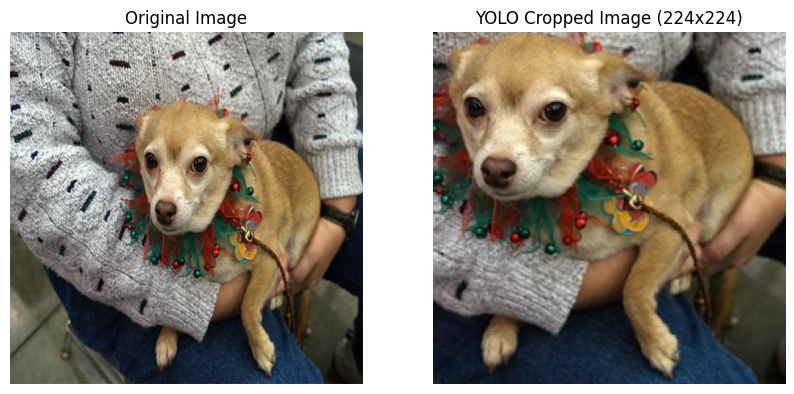

In [ ]:
# 1. CLIP 표준 해상도인 224x224로 리사이즈 (배경 노이즈가 제거된 순수 동물 이미지)
cropped_resized = cropped_animal.resize((224, 224))

# 2. 결과 이미지 저장 (나중에 CLIP 인코더에 집어넣을 소스 파일이 됩니다)
cropped_resized.save('cropped_animal_input.jpg')

# 3. 코랩 화면에 원본과 크롭된 이미지 비교 플롯 출력
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(cropped_resized)
axes[1].set_title("YOLO Cropped Image (224x224)")
axes[1].axis('off')

plt.show()

In [ ]:
# 1. CLIP 구동을 위한 패키지 설치 (최초 1회)
!pip install transformers torch
!pip install -q ultralytics

# 2. 필요한 라이브러리 임포트
import torch
from transformers import CLIPProcessor, CLIPModel
import torch.nn.functional as F

# 3. OpenAI의 표준 CLIP 모델과 프로세서 로드
model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

print("✅ CLIP 모델 로드 완료!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ CLIP 모델 로드 완료!


In [ ]:
# 비교할 후보 텍스트 리스트를 정의합니다.
text_queries = [
    "a brown dog with christmas decorations",       # 1번 후보 (정답 예측)
    "a black cat sleeping on the sofa",            # 2번 후보 (완전 오답)
    "a white poodle playing with a ball",          # 3번 후보 (색상/품종 오답)
    "a person wearing a grey sweater"              # 4번 후보 (배경에 있던 사람 묘사)
]

In [ ]:
# 1. 이미지와 텍스트를 CLIP 입력 규격에 맞게 인코딩합니다.
# 아까 1단계에서 만든 'cropped_resized' 이미지를 그대로 사용합니다.
inputs = processor(
    text=text_queries,
    images=cropped_resized,
    return_tensors="pt",
    padding=True
)

# 2. 모델을 거쳐 이미지 벡터와 텍스트 벡터 추출
with torch.no_grad():
    outputs = clip_model(**inputs)

    # 이미지와 텍스트의 유사도 점수(Logits) 가져오기
    logits_per_image = outputs.logits_per_image  # 이미지 기준의 점수

    # 0~100% 확률 점수(Softmax)로 변환
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

print("📊 매칭 테스트 결과:")
print("-" * 50)

# 각 텍스트 후보별 점수 출력
for text, prob in zip(text_queries, probs):
    print(f"📄 문장: '{text}'")
    print(f"📈 매칭 확률: {prob * 100:.2f}%")
    print("-" * 50)

📊 매칭 테스트 결과:
--------------------------------------------------
📄 문장: 'a brown dog with christmas decorations'
📈 매칭 확률: 99.75%
--------------------------------------------------
📄 문장: 'a black cat sleeping on the sofa'
📈 매칭 확률: 0.00%
--------------------------------------------------
📄 문장: 'a white poodle playing with a ball'
📈 매칭 확률: 0.00%
--------------------------------------------------
📄 문장: 'a person wearing a grey sweater'
📈 매칭 확률: 0.25%
--------------------------------------------------


In [ ]:
# 1. 필수 패키지 설치
print("⚙️ 1단계: 필수 패키지(YOLO, CLIP)를 설치합니다...")
!pip install -q ultralytics transformers

import os
import glob
import numpy as np
import torch
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO
from transformers import CLIPProcessor, CLIPModel

# 2. 깃허브 저장소 연결 (YOLO best.pt 사용 목적)
if not os.path.exists('/content/SafeSight'):
    print("\n🔄 2단계: 깃허브에서 SafeSight 저장소를 가져오는 중...")
    !git clone -b feat/YOLO https://github.com/Yeondu428/SafeSight.git
else:
    print("\n✅ 2단계: SafeSight 저장소가 이미 준비되어 있습니다.")

# 3. 강아지 압축 파일 이름 자동 찾기 및 압축 해ze
print("\n📦 3단계: 강아지 압축 파일 탐색 및 해제 중...")
!rm -rf /content/mydataset/dog
!mkdir -p /content/mydataset/dog

# 왼쪽 파일창에 있는 .zip 파일을 자동으로 찾습니다. (이름이 달라도 해결 가능!)
zip_files = glob.glob('/content/*.zip')
if not zip_files:
    print("❌ [에러] 왼쪽 파일 창에 .zip 파일이 보이지 않습니다! 업로드가 완료되었는지 확인해주세요.")
else:
    # SafeSight 내부의 다른 zip이 있다면 제외하고 제일 최근 올린 강아지 zip 선택
    target_zip = [z for z in zip_files if "cat" not in z.lower()][0]
    print(f"📦 발견된 강아지 압축파일: {target_zip}")

    # 압축 해제 명령 실행
    !unzip -q "{target_zip}" -d /content/mydataset/dog
    print("✅ 압축 해제가 완료되었습니다.")

# 4. 🔥 폴더 구조 검증 및 이미지 싹 긁어모으기
search_pattern = '/content/mydataset/dog/**/*'
all_files = glob.glob(search_pattern, recursive=True)

# 하위 폴더 깊숙이 숨은 이미지까지 확장자 불문 전부 수집
image_paths = [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]

print("\n📊 [경로 검증 결과]")
print(f"──> 압축 해제 공간에 풀린 총 파일/폴더 수: {len(all_files)}개")
print(f"──> 🎯 AI 모델이 찾아낸 최종 강아지 이미지 개수: {len(image_paths)}장")

# 5. AI 연산 가동
if len(image_paths) == 0:
    print("\n❌ 여전히 0장입니다! 압축파일을 더블클릭해서 내부에 실제 이미지(.jpg, .png)들이 들어있는지 확인해주세요.")
else:
    print(f"\n✅ 성공! {len(image_paths)}장으로 강아지 임베딩 벡터 DB 구축을 시작합니다. 🚀")
    print("-" * 50)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # YOLO 가중치 로드
    model_path = '/content/SafeSight/models/best.pt'
    yolo_model = YOLO(model_path).to(device)

    # CLIP 모델 로드
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    all_embeddings = []
    valid_image_paths = []

    # 크롭 + 임베딩 전처리 루프
    for path in tqdm(image_paths, desc="Processing Dog Datasets"):
        try:
            img = Image.open(path).convert('RGB')

            # YOLO 크롭
            yolo_results = yolo_model(img, verbose=False)
            boxes = yolo_results[0].boxes
            cropped_img = None

            for box in boxes:
                if float(box.conf[0]) >= 0.4:
                    xyxy = box.xyxy[0].tolist()
                    cropped_img = img.crop((int(xyxy[0]), int(xyxy[1]), int(xyxy[2]), int(xyxy[3])))
                    break

            if cropped_img is None:
                cropped_img = img

            # CLIP 전처리
            cropped_img = cropped_img.resize((224, 224))
            inputs = processor(images=cropped_img, return_tensors="pt").to(device)

            with torch.no_grad():
                image_features = clip_model.get_image_features(**inputs)
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)
                feature_numpy = image_features.cpu().numpy()[0]

            all_embeddings.append(feature_numpy)
            valid_image_paths.append(path)
        except:
            continue

    # 6. 넘파이 데이터베이스 파일 최종 저장
    np.save('/content/shelter_embeddings.npy', np.array(all_embeddings, dtype=np.float32))
    np.save('/content/shelter_paths.npy', np.array(valid_image_paths))

    print("\n🎉 강아지 벡터 데이터베이스(DB) 구축 완료!")
    print(f"💾 결과 저장 성공! 행렬 크기: {np.array(all_embeddings).shape}")


⚙️ 1단계: 필수 패키지(YOLO, CLIP)를 설치합니다...

🔄 2단계: 깃허브에서 SafeSight 저장소를 가져오는 중...
Cloning into 'SafeSight'...
remote: Enumerating objects: 134, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 134 (delta 15), reused 10 (delta 9), pack-reused 106 (from 1)
Receiving objects: 100% (134/134), 10.25 MiB | 32.09 MiB/s, done.
Resolving deltas: 100% (54/54), done.

📦 3단계: 강아지 압축 파일 탐색 및 해제 중...
❌ [에러] 왼쪽 파일 창에 .zip 파일이 보이지 않습니다! 업로드가 완료되었는지 확인해주세요.

📊 [경로 검증 결과]
──> 압축 해제 공간에 풀린 총 파일/폴더 수: 0개
──> 🎯 AI 모델이 찾아낸 최종 강아지 이미지 개수: 0장

❌ 여전히 0장입니다! 압축파일을 더블클릭해서 내부에 실제 이미지(.jpg, .png)들이 들어있는지 확인해주세요.



image 1/1 /content/n02085620_2053_jpg.rf.7a8c1aa15425153f77d5bc3c059abbb8.jpg: 640x640 (no detections), 402.4ms
Speed: 8.8ms preprocess, 402.4ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)


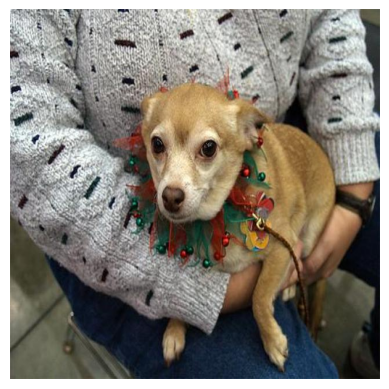

In [12]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

# 모델 로드
model = YOLO('/content/SafeSight/models/best.pt')

# 테스트 이미지 추론
results = model.predict(source='/content/n02085620_2053_jpg.rf.7a8c1aa15425153f77d5bc3c059abbb8.jpg', conf=0.4)

# 시각화 (결과를 이미지로 그려서 출력)
for r in results:
    im_array = r.plot() # Bounding box가 그려진 결과 이미지
    plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [25]:
# 1. 필수 라이브러리 설치
!pip install ultralytics

# 2. 구글 드라이브 마운트
from google.colab import drive
import os
from ultralytics import YOLO

# 3. 경로 설정 (SafeSight 폴더 내부 확인)
# 본인의 실제 폴더 구조와 일치하는지 확인하세요
base_path = '/content/SafeSight'
model_path = os.path.join(base_path, 'models/best.pt')
data_yaml_path = os.path.join(base_path, 'data/data.yaml')

print(f"✅ 모델 경로 확인: {model_path}")
print(f"✅ 데이터셋 경로 확인: {data_yaml_path}")

✅ 모델 경로 확인: /content/SafeSight/models/best.pt
✅ 데이터셋 경로 확인: /content/SafeSight/data/data.yaml


In [26]:
# 모델 로드
if os.path.exists(model_path):
    yolo_model = YOLO(model_path)
    print("✨ 모델 로드 성공!")

    # 모델 정보 출력 (질문하셨던 모델 구조 확인)
    yolo_model.info()
    print(f"\n탐지 클래스: {yolo_model.names}")
else:
    print("❌ 모델 파일을 찾을 수 없습니다. 경로를 다시 확인해주세요!")

✨ 모델 로드 성공!
Model summary: 130 layers, 3,352,200 parameters, 0 gradients, 9.8 GFLOPs

탐지 클래스: {0: 'Afghan_hound', 1: 'African_hunting_dog', 2: 'Airedale', 3: 'American_Staffordshire_terrier', 4: 'Appenzeller', 5: 'Australian_terrier', 6: 'Bedlington_terrier', 7: 'Bernese_mountain_dog', 8: 'Blenheim_spaniel', 9: 'Border_collie', 10: 'Border_terrier', 11: 'Boston_bull', 12: 'Bouvier_des_Flandres', 13: 'Brabancon_griffon', 14: 'Brittany_spaniel', 15: 'Cardigan', 16: 'Chesapeake_Bay_retriever', 17: 'Chihuahua', 18: 'Dandie_Dinmont', 19: 'Doberman', 20: 'English_foxhound', 21: 'English_setter', 22: 'English_springer', 23: 'EntleBucher', 24: 'Eskimo_dog', 25: 'French_bulldog', 26: 'German_shepherd', 27: 'German_short-haired_pointer', 28: 'Gordon_setter', 29: 'Great_Dane', 30: 'Great_Pyrenees', 31: 'Greater_Swiss_Mountain_dog', 32: 'Ibizan_hound', 33: 'Irish_setter', 34: 'Irish_terrier', 35: 'Irish_water_spaniel', 36: 'Irish_wolfhound', 37: 'Italian_greyhound', 38: 'Japanese_spaniel', 39: 'Ke